In [26]:
from preprocess.helper_ply import read_ply

In [82]:
import open3d as o3d
import numpy as np
from plyfile import PlyData

path = "/home/pavel/ITMO/NIR2/data/mend_line5_full.ply"

# --- 1. Читаем PLY и гарантированно получаем XYZ+RGB ---
ply = PlyData.read(path)
vertex = ply["vertex"]

# Извлекаем координаты
x = vertex["x"]
y = vertex["y"]
z = vertex["z"]
points = np.vstack([x, y, z]).T  # (N,3)

# Извлекаем цвета, если есть
if all(c in vertex.data.dtype.names for c in ("red", "green", "blue")):
    r = vertex["red"]
    g = vertex["green"]
    b = vertex["blue"]
    # приводим к [0,255] uint8
    colors = np.vstack([r, g, b]).T.astype(np.uint8)
else:
    print("[WARN] Цветов нет — ставлю белый")
    colors = np.full((points.shape[0], 3), 255, dtype=np.uint8)

print("Points:", points.shape)
print("Colors:", colors.shape)

# --- 2. Центрируем координаты ---
points = points - points.min(axis=0)  # вычитаем min по X,Y,Z

# --- 3. Swap Y & Z (X, Z, Y) ---
# points = points[:, [0, 2, 1]] 

# --- 4. Собираем Nx6 массив ---
data = np.concatenate([points, colors], axis=1)

print("Final data shape:", data.shape)  # должно быть (N, 6)
print("Datatype:", data.dtype)
print("X range:", (points[:,0].min(), points[:,0].max()))
print("Y range:", (points[:,1].min(), points[:,1].max()))
print("Z range:", (points[:,2].min(), points[:,2].max()))
print("RGB min/max:", colors.min(), colors.max())


Points: (11210449, 3)
Colors: (11210449, 3)
Final data shape: (11210449, 6)
Datatype: float32
X range: (0.0, 286.45398)
Y range: (0.0, 280.34308)
Z range: (0.0, 34.99195)
RGB min/max: 0 255


In [83]:
data.shape

(11210449, 6)

In [145]:
from tqdm import tqdm

def generate_bev_tiles_from_data_v2(
    data,
    voxel_size=0.2,
    tile_grid_size=(512, 512),
    stride_px=None,
    height_range=(0, 50),
    min_points_per_tile=2000,
    max_tiles = 10,
):
    """
    Делит облако точек на BEV-тайлы с оверлапом, используя размер в пикселях.

    Аргументы:
        data (np.ndarray): Nx6 массив [x, y, z, r, g, b]
        voxel_size (float): размер в метрах одного пикселя
        tile_grid_size (tuple): (H, W) размер тайла в пикселях
        stride_px (int или tuple): шаг окна в пикселях (если None, будет 50% от tile size)
        height_range (tuple): допустимый диапазон высот
        min_points_per_tile (int): минимальное число точек в тайле, чтобы его сохранить

    Возвращает:
        tiles: список ((x_px, y_px), bev_tile)
    """
    assert data.shape[1] >= 6, "Ожидается [x, y, z, r, g, b]"
    H, W = tile_grid_size
    if stride_px is None:
        stride_px = (H // 2, W // 2)
    elif isinstance(stride_px, int):
        stride_px = (stride_px, stride_px)

    xyz = data[:, :3]
    rgb = data[:, 3:]

    # Фильтрация по Z
    mask = (xyz[:, 2] >= height_range[0]) & (xyz[:, 2] <= height_range[1])
    xyz = xyz[mask]
    rgb = rgb[mask]

    xy = xyz[:, :2]
    z = xyz[:, 2]

    # Смещение координат
    min_xy = xy.min(0)
    xy -= min_xy
    max_xy = xy.max(0)

    ij_all = (xy / voxel_size).astype(int)
    grid_W = int(np.ceil(max_xy[0] / voxel_size))
    grid_H = int(np.ceil(max_xy[1] / voxel_size))

    tiles = []
    for y0 in tqdm(range(0, grid_H - H + 1, stride_px[0])):
        for x0 in tqdm(range(0, grid_W - W + 1, stride_px[1])):
            x1, y1 = x0 + W, y0 + H
            mask_tile = (
                (ij_all[:, 0] >= x0) & (ij_all[:, 0] < x1) &
                (ij_all[:, 1] >= y0) & (ij_all[:, 1] < y1)
            )
            if not np.any(mask_tile):
                continue

            local_xyz = xyz[mask_tile]
            local_rgb = rgb[mask_tile]

            tile_origin = min_xy + np.array([x0, y0]) * voxel_size
            local_xy = local_xyz[:, :2] - tile_origin
            local_ij = (local_xy / voxel_size).astype(int)
            local_z = local_xyz[:, 2]

            bev = np.zeros((H, W, 5), dtype=np.float32)
            for (i, j), h, (r, g, b) in zip(local_ij, local_z, local_rgb):
                if 0 <= j < H and 0 <= i < W:
                    bev[j, i, 1] = max(bev[j, i, 1], h)
                    bev[j, i, 2] += r
                    bev[j, i, 3] += g
                    bev[j, i, 4] += b
                    bev[j, i, 0] += 1

            if bev[..., 0].sum() < min_points_per_tile:
                continue

            nonzero = bev[..., 0] > 0
            bev[nonzero, 2:] /= bev[nonzero, 0:1]

            tiles.append(((x0, y0), bev))
            if len(tiles) > max_tiles:
                return tiles

    return tiles


In [146]:
import matplotlib.pyplot as plt

def quick_bev_preview(data, voxel_size=0.2, height_range=(0, 50), grid_size=(512, 512)):
    """
    Быстрая генерация BEV и визуализация для проверки ориентации.

    Аргументы:
        data (np.ndarray): Nx6 массив [x, y, z, r, g, b]
        voxel_size (float): размер одного пикселя в метрах
        height_range (tuple): диапазон высот
        grid_size (tuple): размер карты в пикселях (H, W)

    Возвращает:
        bev (np.ndarray): BEV-карта (H, W, 5)
    """
    xyz = data[:, :3]
    rgb = data[:, 3:]

    # Z как высота (по умолчанию 3-я координата)
    mask = (xyz[:, 2] >= height_range[0]) & (xyz[:, 2] <= height_range[1])
    xyz = xyz[mask]
    rgb = rgb[mask]

    # Сдвиг в (0, 0)
    min_xy = xyz[:, :2].min(0)
    xyz[:, :2] -= min_xy
    ij = (xyz[:, :2] / voxel_size).astype(int)

    H, W = grid_size
    mask = (ij[:, 0] < W) & (ij[:, 1] < H)
    ij = ij[mask]
    z = xyz[mask, 2]
    rgb = rgb[mask]

    bev = np.zeros((H, W, 5), dtype=np.float32)
    for (i, j), h, (r, g, b) in zip(ij, z, rgb):
        bev[j, i, 1] = max(bev[j, i, 1], h)
        bev[j, i, 2:] += [r, g, b]
        bev[j, i, 0] += 1

    nonzero = bev[..., 0] > 0
    bev[nonzero, 2:] /= bev[nonzero, 0:1]

    # Визуализация RGB
    rgb_img = bev[..., 2:5].astype(np.uint8)
    plt.figure(figsize=(8, 8))
    plt.imshow(rgb_img.transpose(1, 0, 2), origin='lower')
    plt.title("Quick BEV RGB Preview")
    plt.axis('off')
    plt.show()

    return bev


In [147]:
import matplotlib.pyplot as plt

def visualize_bev(bev):
    dens = bev[..., 0]
    rgb = bev[..., 2:5].astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Density")
    plt.imshow(dens, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("RGB (mean)")
    plt.imshow(rgb)
    plt.show()

In [148]:
from pprint import pprint

print("Пример точек:")
pprint(data[np.random.choice(len(data), 5, replace=False)])


Пример точек:
array([[ 62.53006  , 100.36146  ,   5.331603 ,  92.       ,  81.       ,
         72.       ],
       [235.18974  , 142.69997  ,   6.394017 ,   6.       ,   6.       ,
          4.       ],
       [158.5857   ,  81.73814  ,   5.3864975,  87.       ,  83.       ,
         88.       ],
       [185.22198  ,  67.01408  ,   8.309899 ,  92.       ,  84.       ,
         64.       ],
       [202.78755  , 153.27658  ,  14.786547 , 255.       , 218.       ,
        120.       ]], dtype=float32)


In [149]:
x_min, x_max = data[:, 0].min(), data[:, 0].max()
y_min, y_max = data[:, 1].min(), data[:, 1].max()
z_min, z_max = data[:, 2].min(), data[:, 2].max()

print(f"X: {x_min:.2f} — {x_max:.2f}")
print(f"Y: {y_min:.2f} — {y_max:.2f}")
print(f"Z: {z_min:.2f} — {z_max:.2f}")


X: 0.00 — 286.45
Y: 0.00 — 280.34
Z: 0.00 — 34.99


In [150]:
# z_min, z_max = data[:, 2].min(), data[:, 2].max()
# print(f"Диапазон высот: {z_min:.2f} .. {z_max:.2f}")
# quick_bev_preview(data)

In [176]:
# height_range: автоматически подстроим под реальные данные

z_min, z_max = data[:, 2].min(), data[:, 2].max()
print(f"Диапазон высот: {z_min:.2f} .. {z_max:.2f}")
 

bevs = generate_bev_tiles_from_data_v2(
    data,
    voxel_size=0.4,
    stride_px=256,
    tile_grid_size=(300, 300),
    height_range=(z_min, z_max),
    min_points_per_tile=20000,
    max_tiles = 10,
)



Диапазон высот: 0.00 .. 34.99


100%|██████████| 2/2 [00:34<00:00, 17.22s/it]


In [184]:
256 + 64

320

In [177]:
len(bevs)

4

In [183]:
for b in bevs:
    print(b[0])

(0, 0)
(256, 0)
(0, 256)
(256, 256)


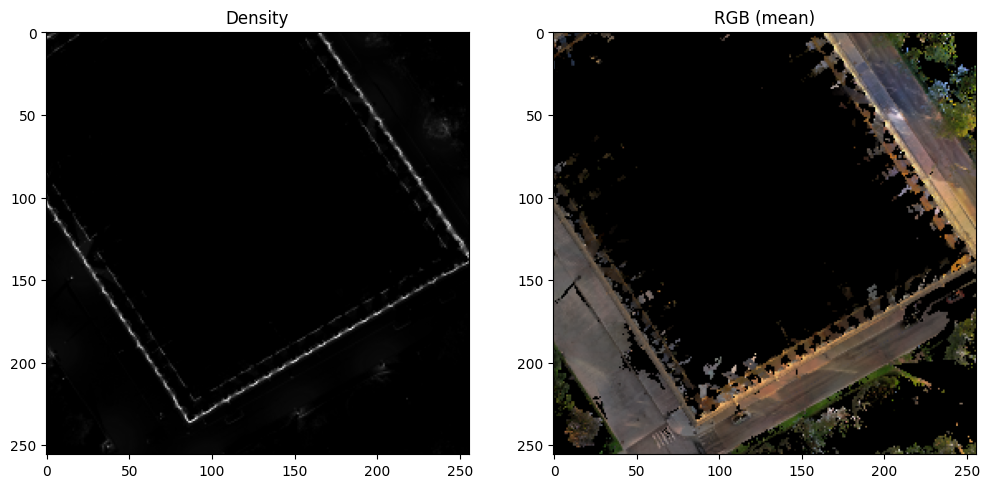

In [182]:

visualize_bev(bevs[3][-1])

In [69]:
import matplotlib.pyplot as plt

# Возьмём только RGB-каналы (средние значения цвета)
rgb = bev[..., 2:5].astype(np.uint8)
rgb = rgb.transpose(1, 0, 2)  # чтобы X→горизонталь, Y→вертикаль

# Сохраняем
plt.imsave("/home/pavel/ITMO/NIR2/data/BEV/RS10.png", rgb)
print("Сохранено как bev_rgb.png")


Сохранено как bev_rgb.png


In [185]:
import numpy as np
import matplotlib.pyplot as plt

def stitch_bev_tiles(tiles, tile_shape=(512, 512), channels=(2, 3, 4)):
    """
    Сшивает BEV-тайлы обратно в одну RGB-карту.

    Аргументы:
        tiles (list): список ((x_px, y_px), bev) тайлов
        tile_shape (tuple): форма одного тайла (H, W)
        channels (tuple): какие каналы использовать как RGB (по умолчанию r,g,b)

    Возвращает:
        full_rgb (np.ndarray): HxWx3 RGB изображение
    """
    H, W = tile_shape

    # Определим максимальные размеры итоговой карты
    max_x = max(x for (x, y), _ in tiles) + W
    max_y = max(y for (x, y), _ in tiles) + H

    stitched = np.zeros((max_y, max_x, 3), dtype=np.uint8)
    count_map = np.zeros((max_y, max_x), dtype=np.uint16)

    for (x, y), bev in tiles:
        tile_rgb = bev[..., list(channels)]
        tile_rgb = np.clip(tile_rgb, 0, 255).astype(np.uint8)

        # Накопление
        stitched[y:y+H, x:x+W] += tile_rgb
        count_map[y:y+H, x:x+W] += (tile_rgb[..., 0] > 0).astype(np.uint8)

    # Усреднение по количеству накладок
    nonzero_mask = count_map > 0
    stitched[nonzero_mask] = (stitched[nonzero_mask].astype(np.float32) / count_map[nonzero_mask, None]).astype(np.uint8)

    return stitched

# Визуализация
def show_stitched_bev(stitched_img):
    plt.figure(figsize=(10, 10))
    plt.imshow(stitched_img)
    plt.title("Сшитая BEV-карта")
    plt.axis('off')
    plt.show()


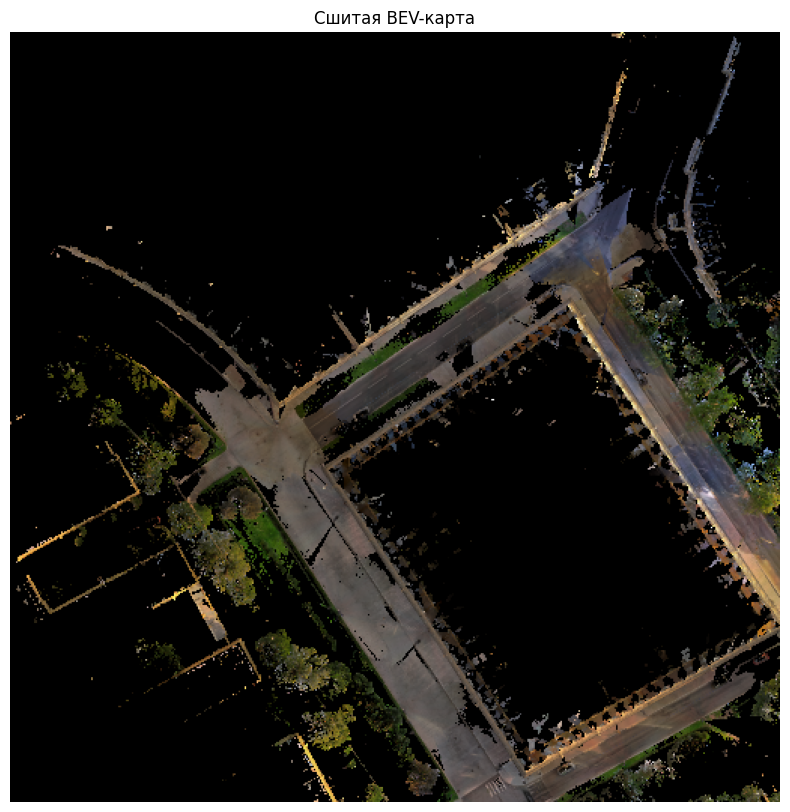

In [187]:
tile_h, tile_w = bevs[0][1].shape[:2]
stitched = stitch_bev_tiles(bevs, tile_shape=(tile_h, tile_w))
show_stitched_bev(stitched)


In [2]:
import cv2
image = cv2.imread("/home/pavel/ITMO/NIR2/data/out_BEV/rgb/RS10_-13270_-178.png")
cv2.imshow("Image", image)

In [5]:
import numpy as np
np.unique(image)

array([0], dtype=uint8)

In [6]:
import sys
sys.path.insert(0, "/home/pavel/ITMO/NIR2/SensatUrban-BEV-Seg3D/preprocess")
from helper_ply import read_ply

ply = "/home/pavel/ITMO/NIR2/data/RS10.ply"
data = read_ply(ply)
print(data.dtype.names)


('x', 'y', 'z', 'red', 'green', 'blue', 'alpha')


In [7]:
import sys
sys.path.insert(0, "/home/pavel/ITMO/NIR2/SensatUrban-BEV-Seg3D/preprocess")
from helper_ply import read_ply

ply = "/home/pavel/ITMO/NIR2/data/new_tiles/RS10/tile_019.ply"
d = read_ply(ply)
print(d.dtype.names)
for k in ["red","green","blue","alpha","x","y","z"]:
    if k in d.dtype.names:
        v = d[k]
        print(k, v.dtype, v.min(), v.max())


('x', 'y', 'z', 'red', 'green', 'blue')
red uint8 4 235
green uint8 4 234
blue uint8 5 234
x float64 -13297.05859375 -13283.05859375
y float64 -173.98199462890625 -170.68699645996094
z float64 -11007.033203125 -10999.033203125


In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/home/pavel/ITMO/NIR2/SensatUrban-BEV-Seg3D/preprocess")
from helper_ply import read_ply

def remap_axes(xyz, coord_order="xyz", bev_axes="xy", height_axis="z"):
    axes = {"x":0,"y":1,"z":2}
    reorder = [coord_order.index("x"), coord_order.index("y"), coord_order.index("z")]
    xyz = xyz[:, reorder].copy()
    bx, by, hz = axes[bev_axes[0]], axes[bev_axes[1]], axes[height_axis]
    xyz = xyz[:, [bx, by, hz]]
    return xyz  # now [x,y,z] in desired frame

def bev_tile(xyz, rgb, voxel=0.2, size=(256,256), origin=None):
    H, W = size
    if origin is None:
        origin = xyz[:, :2].min(0)
    xy = xyz[:, :2] - origin
    ij = (xy / voxel).astype(int)
    z = xyz[:, 2]

    img = np.zeros((H, W, 3), dtype=np.float32)
    zbuf = np.full((H, W), -1e9, dtype=np.float32)
    for (i,j), h, (r,g,b) in zip(ij, z, rgb):
        if 0 <= j < H and 0 <= i < W:
            if h > zbuf[j, i]:
                zbuf[j, i] = h
                img[j, i] = (r, g, b)
    if img.max() <= 1.0:
        img *= 255.0
    return img.astype(np.uint8)

# --- usage ---
ply = "/home/pavel/ITMO/NIR2/data/RS10.ply"
data = read_ply(ply)

xyz = np.vstack([data["x"], data["y"], data["z"]]).T
rgb = np.vstack([data["red"], data["green"], data["blue"]]).T

xyz = remap_axes(xyz, coord_order="xyz", bev_axes="xy", height_axis="z")  # меняй тут

tile = bev_tile(xyz, rgb, voxel=0.2, size=(256,256))
plt.imshow(tile[..., ::-1])  # BGR->RGB, если надо
plt.axis("off")
